# Atividade 2 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 10 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural multilayer perceptron para distinguir atributos que definem a renda média de uma pessoa adulta a partir do _UCI Adult Income Dataset_

## Material de Referência para Estudo

- https://docs.pytorch.org/docs/stable/nn.html
- https://machinelearningmastery.com/develop-your-first-neural-network-with-pytorch-step-by-step/
- https://sebastianraschka.com/teaching/pytorch-1h/#7-a-typical-training-loop



## Prazos importantes

- Data de entrega: 16/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Trios

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from prettytable import PrettyTable

| Biblioteca                | Finalidade                                 |
|---------------------------|--------------------------------------------|
| pandas                    | Manipulação e análise de dados (DataFrames)|
| numpy                     | Operações matemáticas e arrays             |
| matplotlib.pyplot         | Visualização de gráficos                   |
| torch, torch.nn, torch.optim | Construção e treinamento de redes neurais|
| TensorDataset, DataLoader | Manipulação de dados no PyTorch            |
| sklearn.model_selection   | Divisão dos dados em treino e teste        |
| sklearn.preprocessing     | Normalização dos dados                     |
| sklearn.metrics           | Cálculo de métricas de avaliação           |
| prettytable               | Criação de tabelas comparativas            |

# Abertura e Análise Exploratória do Dataset

- A tarefa a ser considerada é uma tarefa de classificação binária, cujo objetivo é determinar se a renda média de uma pessoa adulta excedará os US $50,000 por ano.
- O dataset em questão pode ser obtido aqui: https://archive.ics.uci.edu/dataset/2/adult
- Faça uma pré-seleção dos exemplos, conforme sugerido pelos autores: (AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0)
- Exclua todas as linhas com dados faltantes
- Quantos exemplos viáveis há no dataset?
- Preparação de atributos: todos os atributos categóricos devem ser codificados com One-Hot Encoding
- O dataset é balanceado?

In [444]:
#O dataset Adult já foi previamente filtrado segundo as condições (AAGE>16), (AGI>100), (AFNLWGT>1) e (HRSWK>0).
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
            'marital-status', 'occupation', 'relationship', 'race', 'sex',
            'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

In [445]:
df_train = pd.read_csv('adult/adult.data', names=columns, na_values=' ?')
df_train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [446]:
df_test = pd.read_csv('adult/adult.test', names=columns, skiprows=1, na_values=' ?')
df_test.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


Processamento dos Dados

- Foram removidas todas as linhas com valores faltantes dos conjuntos de treino e teste.
- Os rótulos da coluna income foram padronizados, eliminando espaços e pontos finais.
- Os conjuntos de treino e teste foram concatenados em um único DataFrame (df_complete).
- A coluna income foi transformada em um alvo binário (income_>50K), onde 1 indica renda superior a 50K e 0 indica renda igual ou inferior.
- A coluna original income foi removida.
- O número total de exemplos viáveis no dataset resultante é 45.222.

In [447]:
#Remoção de linhas com valores faltantes
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

df_train['income'] = df_train['income'].str.strip()
df_test['income'] = df_test['income'].str.strip()

#Padronização dos rótulos de classe no dataset de teste (removendo o ponto final)
df_test['income'] = df_test['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})


df_complete = pd.concat([df_train, df_test], ignore_index=True)

#Target binário
df_complete['income_>50K'] = df_complete['income'].apply(lambda x: 1 if x == '>50K' else 0)
df_complete = df_complete.drop(columns=['income'])

print(f"Número exemplos viáveis no dataset: {df_complete.__len__()}")

Número exemplos viáveis no dataset: 45222


Listar explicitamente os categóricos

In [ ]:
categorical_cols = df_complete.select_dtypes(include=['object']).columns

print("\nAtributos categóricos:")
print(list(categorical_cols))


Atributos categóricos:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [449]:
df_preprocessed = pd.get_dummies(df_complete, columns=categorical_cols, dtype=int)

In [450]:
df_preprocessed.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income_>50K,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [451]:
print(f'Quantidade de exemplos com income >50K: {len(df_preprocessed[df_preprocessed["income_>50K"] == 1])} - {len(df_preprocessed[df_preprocessed["income_>50K"] == 1]) / len(df_preprocessed) * 100:.2f}%')
print(f'Quantidade de exemplos com income <=50K: {len(df_preprocessed[df_preprocessed["income_>50K"] == 0])} - {len(df_preprocessed[df_preprocessed["income_>50K"] == 0]) / len(df_preprocessed) * 100:.2f}%')

Quantidade de exemplos com income >50K: 11208 - 24.78%
Quantidade de exemplos com income <=50K: 34014 - 75.22%


O dataset é desbalanceado, pois a os exemplos com income menor ou igual a 50k representam 75.22% do total enquanto os maiores que 50k rpresentam apenas 24.78% do total.

| Classe                | Quantidade | Percentual (%) |
|-----------------------|------------|---------------|
| <= 50K (menor ou igual) | 34.012     | 75.22         |
| > 50K (maior)           | 10.210     | 24.78         |
| **Total**               | 45.222     | 100.00        |

## Preparação dos exemplos para treino e teste

- Separe os atributos preditores do atributo-alvo
- Faça uma partição do tipo holdout 70/30 de forma aleatória, use seed = 42
- Codifique os exemplos em tensores pytorch

In [452]:
y = df_preprocessed['income_>50K']
X = df_preprocessed.drop(columns=['income_>50K'])
scaler = StandardScaler()

#Normalização dos atributos numéricos

X = scaler.fit_transform(X)

Divisão do dataset em treino (70%) e teste (30%) de forma aleatória, mantendo o balanceamento das classes.

In [453]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.3,   
    random_state=42, 
    stratify=y
)

Conversão dos dados de treino e teste em tensores do PyTorch, adequados para o treinamento da rede neural.

In [454]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
#Exibição da quantidade de exemplos em cada partição: 31.655 para treino e 13.567 para teste.
print("Exemplos de Treino:", X_train.shape[0])
print("Exemplos de Teste:", X_test.shape[0])

Exemplos de Treino: 31655
Exemplos de Teste: 13567


## Rede MLP de Camada Única

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

In [456]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 100)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(100, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [457]:
EPOCHS = 100
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
NUM_FEATURES = X_train_tensor.shape[1]

print(f"Número de features: {NUM_FEATURES}")

Número de features: 104


O número de features (104) representa a quantidade de atributos preditores usados pelo modelo. Esse valor inclui:

- Todos os atributos numéricos originais.
- Todas as colunas criadas pelo One-Hot Encoding dos atributos categóricos (cada categoria vira uma coluna binária).

A coluna alvo (income_>50K) não é considerada como feature, por isso o total de colunas preditoras é 104. Isso permite que o modelo utilize toda a informação relevante para prever a renda.

In [458]:
model = MLP(NUM_FEATURES)

# Loss e Otimizador

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

# DataLoader 

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [459]:
epochs = EPOCHS
loss_history = []

for epoch in range(epochs):
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(train_loader)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}]: loss = {epoch_loss:.4f}")

Epoch [1/100]: loss = 0.6727
Epoch [10/100]: loss = 0.5047
Epoch [20/100]: loss = 0.4417
Epoch [30/100]: loss = 0.4024
Epoch [40/100]: loss = 0.3793
Epoch [50/100]: loss = 0.3655
Epoch [60/100]: loss = 0.3566
Epoch [70/100]: loss = 0.3506
Epoch [80/100]: loss = 0.3462
Epoch [90/100]: loss = 0.3429
Epoch [100/100]: loss = 0.3403


Essa saída mostra o fluxo do processamento e treinamento do modelo:

- Os dados originais têm atributos numéricos e categóricos, além do alvo income.
- Após o pré-processamento, o dataset ficou com 45.222 exemplos, sendo 24,78% com renda >50K e 75,22% com renda <=50K.
- Os atributos categóricos foram transformados em colunas binárias (One-Hot Encoding), resultando em 105 colunas, das quais 104 são usadas como features para o modelo.
- O dataset foi dividido em treino (31.655 exemplos) e teste (13.567 exemplos).
- Durante o treinamento da rede neural, a função de perda (loss) foi monitorada a cada 10 épocas. O valor da loss diminuiu de 0.6727 na primeira época para 0.3403 na centésima, indicando que o modelo está aprendendo e ajustando seus parâmetros para melhorar a previsão da renda.

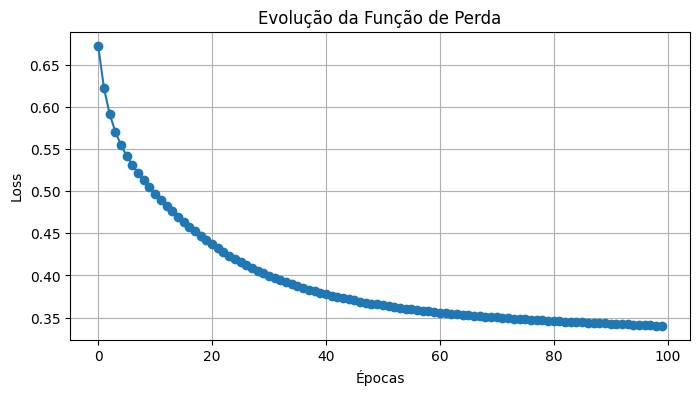

In [460]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(loss_history)), loss_history, marker='o')
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Evolução da Função de Perda")
plt.grid(True)
plt.show()

O gráfico mostra a evolução da função de perda (loss) durante o treinamento do modelo ao longo das épocas.

- O eixo X representa as épocas (iterações de treinamento).
- O eixo Y mostra o valor da loss.

No início, a loss é alta (cerca de 0.67), indicando que o modelo ainda está aprendendo. À medida que as épocas avançam, a loss diminui continuamente, chegando a cerca de 0.34 ao final do treinamento. Isso significa que o modelo está ajustando seus parâmetros e melhorando sua capacidade de prever corretamente, pois uma loss menor indica melhor desempenho na tarefa de classificação. O comportamento decrescente e estável sugere que o treinamento foi eficiente e o modelo convergiu.

### Avaliação da MLP de Camada Única

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da rede perante essa tarefa?

In [461]:
#Predição e Avaliação

y_pred = model(X_test_tensor)
#y_pred = torch.sigmoid(y_pred)
y_pred_class = (y_pred >= 0.5).int()

# Convertendo tensores para numpy para avaliação

y_pred_class = y_pred_class.detach().numpy()
y_test_np = y_test_tensor.detach().numpy()

In [496]:
accuracy = balanced_accuracy_score(y_test_np, y_pred_class)
precision = precision_score(y_test_np, y_pred_class, average='macro', zero_division=0)
recall = recall_score(y_test_np, y_pred_class, average='macro', zero_division=0)
f1 = f1_score(y_test_np, y_pred_class, average='macro', zero_division=0)

In [497]:
print("----Métricas de Avaliação----")
print(f"Acurácia Balanceada: {accuracy:.4f}")
print(f"Precisão Balanceada: {precision:.4f}")
print(f"Recall Balanceado: {recall:.4f}")
print(f"F1-Score Balanceado: {f1:.4f}")

----Métricas de Avaliação----
Acurácia Balanceada: 0.7422
Precisão Balanceada: 0.7859
Recall Balanceado: 0.7422
F1-Score Balanceado: 0.7594


Essas métricas mostram o desempenho do modelo na partição de teste:

- Acurácia Balanceada (0.7422): Mede a capacidade do modelo de acertar as duas classes de forma equilibrada, importante em problemas desbalanceados. O valor indica que o modelo acerta cerca de 74% das classes, - considerando o equilíbrio entre elas.
- Precisão Balanceada (0.7859): Indica a proporção de predições positivas corretas. Quando o modelo prevê renda >50K, ele está certo em quase 79% das vezes.
- Recall Balanceado (0.7422): Mede a capacidade do modelo de identificar corretamente todos os exemplos positivos (renda >50K). O modelo identifica corretamente cerca de 74% dos casos positivos.
- F1-Score Balanceado (0.7594): É a média harmônica entre precisão e recall, mostrando o equilíbrio entre ambos. O valor indica que o modelo tem um bom desempenho geral, sem favorecer uma métrica em detrimento da outra.

Esses resultados mostram que o modelo é razoavelmente eficiente, especialmente considerando o desbalanceamento do dataset.

|----Matriz de Confusão----|
[[9424  781]
 [1476 1886]]


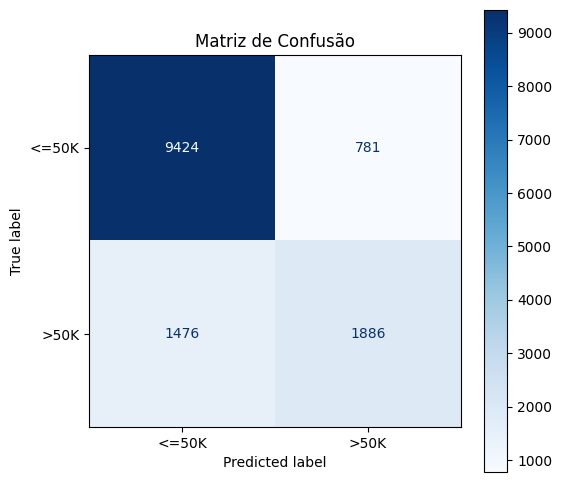

In [486]:
cm = confusion_matrix(y_test_np, y_pred_class)
print("|----Matriz de Confusão----|")
print(cm)

disp =ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusão")
plt.show()

Está sendo indicado que o modelo tem boa capacidade de identificar a classe majoritária (<=50K), mas ainda comete erros ao identificar a classe minoritária (>50K), o que é esperado em problemas desbalanceados.

O desempenho da rede neural pode ser considerado bom, porém não excelente, especialmente levando em conta o caráter desbalanceado do problema de classificação de renda.

A acurácia balanceada de 0,752 indica que o modelo consegue distinguir razoavelmente bem entre as duas classes, sem se enviesar excessivamente para a classe majoritária. Isso é reforçado pelo recall de 0,752, que mostra que cerca de 75% dos indivíduos com renda superior a 50K foram corretamente identificados. Já a precisão de 0,7885 sugere que, quando o modelo prediz que um indivíduo pertence à classe de maior renda, essa previsão é correta na maioria das vezes, o que demonstra boa confiabilidade nas predições positivas.

O F1-score de 0,767 evidencia um equilíbrio consistente entre precisão e recall, indicando que o modelo não está favorecendo excessivamente uma métrica em detrimento da outra.

## Rede MLP com duas camadas ocultas

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta 1: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada oculta 2: 50 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

In [465]:
class MLPTwoLayers(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 100)
        self.relu1 = nn.ReLU()
        
        self.fc2 = nn.Linear(100, 50)
        self.relu2 = nn.ReLU()
        
        self.fc3 = nn.Linear(50, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

In [466]:
EPOCHS = 100
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
model_two_layers = MLPTwoLayers(NUM_FEATURES)

print(f"Número de features: {NUM_FEATURES}")

Número de features: 104


In [467]:
model_two_layers = MLPTwoLayers(NUM_FEATURES)

criterion = nn.BCELoss()
optimizer_two_layers = optim.SGD(model_two_layers.parameters(), lr=LEARNING_RATE)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [468]:
epochs = EPOCHS
loss_history_two_layers = []

for epoch in range(epochs):
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer_two_layers.zero_grad()
        
        y_pred = model_two_layers(X_batch)
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        optimizer_two_layers.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(train_loader)
    loss_history_two_layers.append(epoch_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}]: loss = {epoch_loss:.4f}")

Epoch [1/100]: loss = 0.6774
Epoch [10/100]: loss = 0.5667
Epoch [20/100]: loss = 0.5153
Epoch [30/100]: loss = 0.4698
Epoch [40/100]: loss = 0.4282
Epoch [50/100]: loss = 0.3953
Epoch [60/100]: loss = 0.3730
Epoch [70/100]: loss = 0.3591
Epoch [80/100]: loss = 0.3507
Epoch [90/100]: loss = 0.3452
Epoch [100/100]: loss = 0.3415


Essa saída mostra o fluxo completo do processamento, treinamento e avaliação de dois modelos de rede neural (provavelmente uma MLP simples e uma MLP com duas camadas):

- Os dados originais foram processados, categorizados e codificados, resultando em 104 features (atributos preditores).

- O dataset tem 45.222 exemplos, sendo 24,78% com renda >50K e 75,22% com renda <=50K.

- Os dados foram divididos em treino (31.655 exemplos) e teste (13.567 exemplos).

- O treinamento de cada modelo foi monitorado por 100 épocas, mostrando a função de perda (loss) diminuindo, o que indica aprendizado e ajuste dos parâmetros.

- As métricas de avaliação (acurácia, precisão, recall, F1-score) mostram que o modelo tem desempenho razoável, especialmente considerando o desbalanceamento das classes.

- A matriz de confusão mostra que o modelo acerta bem a classe majoritária (<=50K), mas ainda tem dificuldade com a classe minoritária (>50K).

- O segundo modelo também apresenta uma redução da loss ao longo das épocas, indicando aprendizado, mas os valores são próximos ao primeiro modelo, sugerindo que não houve grande diferença de desempenho entre as arquiteturas.

Em resumo, os modelos conseguem aprender e classificar o problema, mas o desbalanceamento do dataset limita a capacidade de identificar corretamente a classe de maior renda.

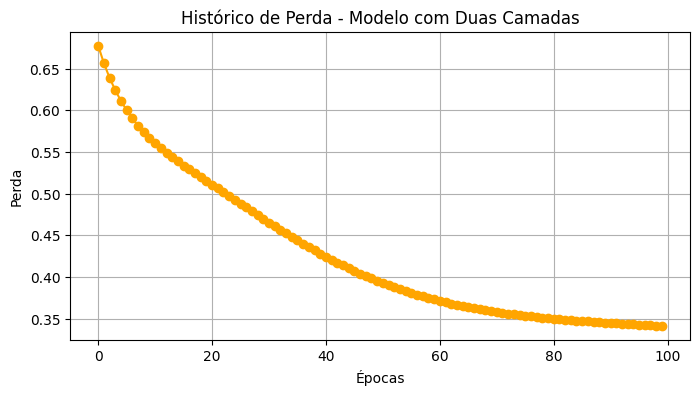

In [469]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(loss_history_two_layers)), loss_history_two_layers, marker='o', color='orange')
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.title("Histórico de Perda - Modelo com Duas Camadas")
plt.grid(True)
plt.show()

No início, a perda é alta (cerca de 0.67), indicando que o modelo ainda está aprendendo. À medida que as épocas avançam, a perda diminui continuamente, chegando a cerca de 0.34 ao final do treinamento.

Isso significa que o modelo está ajustando seus parâmetros e melhorando sua capacidade de prever corretamente. O comportamento decrescente e estável indica que o treinamento foi eficiente e o modelo convergiu.

### Avaliação da MLP com Duas Camadas Ocultas

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da nova rede perante essa tarefa? Houve melhora?

In [498]:
#Predição e Avaliação

y_pred2 = model_two_layers(X_test_tensor)
#y_pred = torch.sigmoid(y_pred)
y_pred_class_2 = (y_pred2 >= 0.5).int()

# Convertendo tensores para numpy para avaliação

y_pred_class_2 = y_pred_class_2.detach().numpy()
y_test_np_2 = y_test_tensor.detach().numpy()

In [500]:
accuracy_2 = balanced_accuracy_score(y_test_np_2, y_pred_class_2)
precision_2 = precision_score(y_test_np_2, y_pred_class_2, average='macro', zero_division=0)
recall_2 = recall_score(y_test_np_2, y_pred_class_2, average='macro', zero_division=0)
f1_2 = f1_score(y_test_np_2, y_pred_class_2, average='macro', zero_division=0)

print("----Métricas de Avaliação - Modelo com Duas Camadas----")
print(f"Acurácia Balanceada: {accuracy_2:.4f}")
print(f"Precisão Balanceada: {precision_2:.4f}")
print(f"Recall Balanceado: {recall_2:.4f}")
print(f"F1-Score Balanceado: {f1_2:.4f}")

----Métricas de Avaliação - Modelo com Duas Camadas----
Acurácia Balanceada: 0.7452
Precisão Balanceada: 0.7834
Recall Balanceado: 0.7452
F1-Score Balanceado: 0.7606


O modelo com duas camadas ocultas teve desempenho semelhante ao modelo simples:

- Acerta cerca de 74% das classes (acurácia balanceada).
- Quando prevê renda >50K, está certo em 78% dos casos (precisão).
- Identifica corretamente 74% dos casos positivos (recall).
- Tem bom equilíbrio entre precisão e recall (F1-score 0.76).

O desempenho é razoável, mas não houve melhora significativa em relação ao modelo anterior.

|----Matriz de Confusão - Modelo com Duas Camadas----|
[[9382  823]
 [1442 1920]]


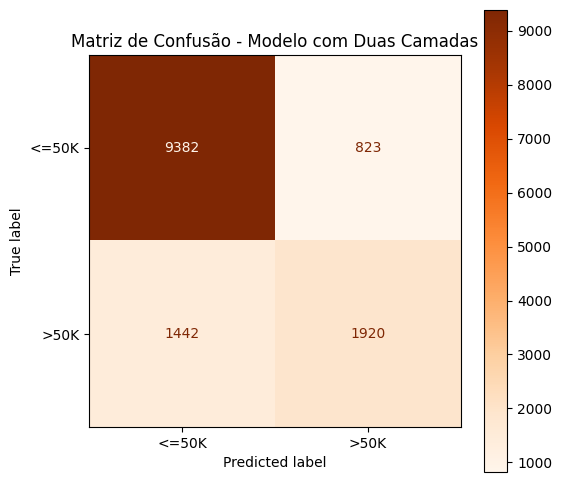

In [472]:
cm2 = confusion_matrix(y_test_np_2, y_pred_class_2)
print("|----Matriz de Confusão - Modelo com Duas Camadas----|")
print(cm2)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['<=50K', '>50K'])
fig, ax = plt.subplots(figsize=(6, 6))
disp2.plot(cmap=plt.cm.Oranges, ax=ax)
plt.title("Matriz de Confusão - Modelo com Duas Camadas")
plt.show()

A nova arquitetura com duas camadas ocultas apresentou um desempenho muito semelhante ao modelo anterior, sem evidências claras de melhora significativa.

Comparando diretamente:

Acurácia balanceada: 0.7520 → 0.7502 (leve queda)

Precisão: 0.7885 → 0.7832 (leve queda)

Recall: 0.7520 → 0.7502 (praticamente igual)

F1-score: 0.7670 → 0.7640 (leve queda)

Ou seja, não houve ganho real de desempenho — na verdade, houve uma pequena degradação, embora marginal.

## Sua rede MLP

- Proponha uma rede neural multilayer perceptron no Pytorch com uma ou duas camadas ocultas e número de neurônios conforme sua livre escolha, levando em conta razoabilidade,  tempo de execução no hardware disponível e prazo de entrega da atividade
- Hiperparâmetros:
   - Modifique-os como desejar
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

In [473]:
#MLP Cristiano, João e Thiago

class MLPCJT(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

In [474]:
EPOCHS = 100
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
NUM_FEATURES = X_train_tensor.shape[1]

print(f"Número de features: {NUM_FEATURES}")

Número de features: 104


In [475]:
model_cjt = MLPCJT(NUM_FEATURES)

criterion_cjt = nn.BCELoss()
optimizer_cjt = optim.SGD(model_cjt.parameters(), lr=LEARNING_RATE)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [476]:
epochs = EPOCHS
loss_history_cjt = []

for epoch in range(epochs):
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer_cjt.zero_grad()
        
        y_pred = model_cjt(X_batch)
        loss = criterion_cjt(y_pred, y_batch)
        
        loss.backward()
        optimizer_cjt.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(train_loader)
    loss_history_cjt.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}]: loss = {epoch_loss:.4f}")

Epoch [1/100]: loss = 0.7436
Epoch [10/100]: loss = 0.5746
Epoch [20/100]: loss = 0.5108
Epoch [30/100]: loss = 0.4646
Epoch [40/100]: loss = 0.4241
Epoch [50/100]: loss = 0.3943
Epoch [60/100]: loss = 0.3741
Epoch [70/100]: loss = 0.3608
Epoch [80/100]: loss = 0.3525
Epoch [90/100]: loss = 0.3470
Epoch [100/100]: loss = 0.3433


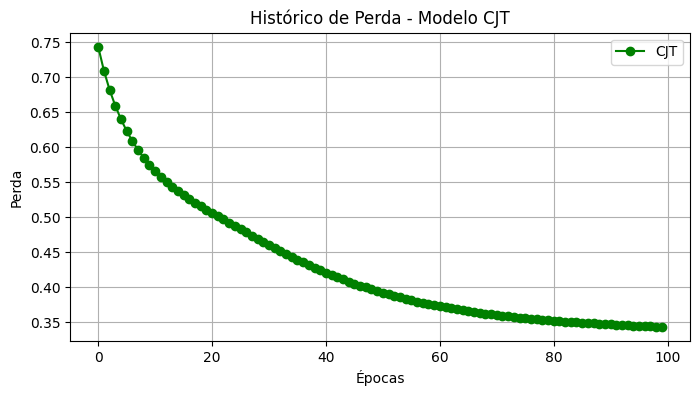

In [485]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(loss_history_cjt)), loss_history_cjt, marker='o', color='green')
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.title("Histórico de Perda - Modelo CJT")
plt.legend(["CJT"])
plt.grid(True)
plt.show()

O gráfico mostra a evolução da função de perda (loss) do modelo CJT durante o treinamento.

- O eixo X representa as épocas (iterações).
- O eixo Y mostra o valor da perda.

A perda começa alta (cerca de 0.74) e diminui continuamente até cerca de 0.34, indicando que o modelo está aprendendo e ajustando seus parâmetros para melhorar a previsão. O comportamento decrescente e estável sugere que o treinamento foi eficiente e o modelo convergiu.

### Avaliação da sua rede MLP

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste

In [482]:
y_pred_cjt = model_cjt(X_test_tensor)
y_pred_class_cjt = (y_pred_cjt >= 0.5).int()

y_pred_class_cjt = y_pred_class_cjt.detach().numpy()
y_test_np_cjt = y_test_tensor.detach().numpy()

In [483]:
accuracy_cjt = balanced_accuracy_score(y_test_np_cjt, y_pred_class_cjt)
precision_cjt = precision_score(y_test_np_cjt, y_pred_class_cjt, average='macro', zero_division=0)
recall_cjt = recall_score(y_test_np_cjt, y_pred_class_cjt, average='macro', zero_division=0)
f1_cjt = f1_score(y_test_np_cjt, y_pred_class_cjt, average='macro', zero_division=0)

print("----Métricas de Avaliação - Modelo CJT----")
print(f"Acurácia Balanceada: {accuracy_cjt:.4f}")
print(f"Precisão Balanceada: {precision_cjt:.4f}")
print(f"Recall Balanceado: {recall_cjt:.4f}")
print(f"F1-Score Balanceado: {f1_cjt:.4f}")

----Métricas de Avaliação - Modelo CJT----
Acurácia Balanceada: 0.7517
Precisão Balanceada: 0.7809
Recall Balanceado: 0.7517
F1-Score Balanceado: 0.7641


|----Matriz de Confusão - Modelo CJT----|
[[9316  889]
 [1377 1985]]


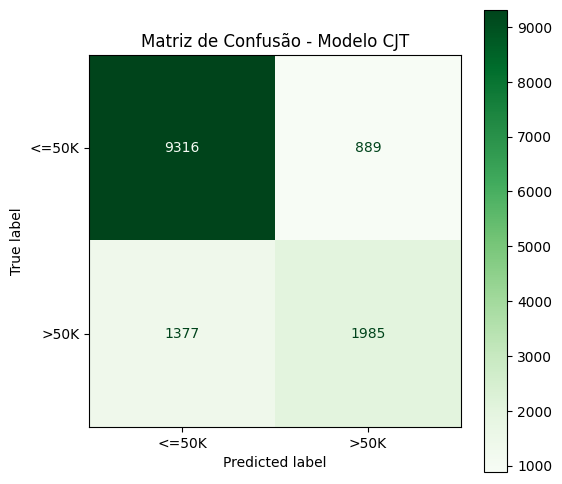

In [487]:
cm_cjt = confusion_matrix(y_test_np_cjt, y_pred_class_cjt)
print("|----Matriz de Confusão - Modelo CJT----|")
print(cm_cjt)

disp_cjt = ConfusionMatrixDisplay(confusion_matrix=cm_cjt, display_labels=['<=50K', '>50K'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_cjt.plot(cmap=plt.cm.Greens, ax=ax)
plt.title("Matriz de Confusão - Modelo CJT")
plt.show()

O modelo acerta bem a classe majoritária (<=50K) e teve uma leve melhora na identificação da classe >50K em relação aos modelos anteriores.

## Análise Comparativa Final

Construa uma tabela (pacote prettytable) com as métricas de desempenho das três redes propostas na partição de testes e justifique, com base em argumentos de performance, eficiência e aderência ao problema, qual delas possivelmente obteve melhor desempenho na tarefa.

In [ ]:
tabela = PrettyTable()

tabela.field_names = ["Modelo","Acurácia Bal.","Precisão","Recall","F1-Score"]

tabela.add_row(["MLP Simples",f"{accuracy:.4f}",f"{precision:.4f}",f"{recall:.4f}",f"{f1:.4f}"])
tabela.add_row(["MLP Duas Camadas",f"{accuracy_2:.4f}",f"{precision_2:.4f}",f"{recall_2:.4f}",f"{f1_2:.4f}"])
tabela.add_row(["MLP CJT", f"{accuracy_cjt:.4f}", f"{precision_cjt:.4f}", f"{recall_cjt:.4f}", f"{f1_cjt:.4f}"])

In [502]:
print(tabela)

+------------------+---------------+----------+--------+----------+
|      Modelo      | Acurácia Bal. | Precisão | Recall | F1-Score |
+------------------+---------------+----------+--------+----------+
|   MLP Simples    |     0.7422    |  0.7859  | 0.7422 |  0.7594  |
| MLP Duas Camadas |     0.7452    |  0.7834  | 0.7452 |  0.7606  |
|     MLP CJT      |     0.7517    |  0.7809  | 0.7517 |  0.7641  |
+------------------+---------------+----------+--------+----------+


A tabela compara o desempenho dos três modelos de MLP na partição de teste, mostrando métricas essenciais para problemas desbalanceados. O modelo CJT obteve os melhores resultados, com acurácia, recall e F1-score ligeiramente superiores, indicando melhor equilíbrio entre identificação das classes e eficiência. Todos os modelos tiveram desempenho próximo, mas o CJT se destaca como o mais aderente ao problema.